In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import datetime
%matplotlib notebook
%matplotlib inline
pd.options.display.max_rows = 150

In [44]:
#reference_date_str = "2026-02-28"
reference_date_str = "2015-01-31"
reference_year = int(reference_date_str[:4])
reference_month = int(reference_date_str[5:7])
reference_day = int(reference_date_str[8:])

In [45]:
country = "EU"

In [46]:
is_va_str = "no_VA"

In [47]:
num_years = 150

In [48]:
start = datetime.date(reference_year+1, reference_month, reference_day)
end = datetime.date(reference_year+num_years-1, reference_month, reference_day)

In [49]:
current_dir = os.getcwd()

In [50]:
data_dir = current_dir + "\\data"

In [51]:
Qb_path = os.path.join(data_dir,"qb_vectors.csv")

In [52]:
all_Qb = pd.read_csv(Qb_path, header=0)

In [53]:
def filter_df_for_selection(df:pd.DataFrame, reference_date_str:str, country_str:str, is_va_str:str)-> pd.DataFrame:
    """
    Filters database for selected country, reference date and VA inclusion.
    """
    df_one = df[
        (df["reference_date"] == reference_date_str) &
        (df["country"] == country_str) &
        (df["curve_type"] == is_va_str)].copy()

    return df_one

In [54]:
all_Qb.head()

,reference_date,curve_type,country,term_index,qb_value
0,2014-12-31,no_VA,AT,1.0,-1.939468
1,2014-12-31,no_VA,AT,2.0,0.897682
2,2014-12-31,no_VA,AT,3.0,-0.309434
3,2014-12-31,no_VA,AT,4.0,0.380559
4,2014-12-31,no_VA,AT,5.0,-0.007954


In [55]:
one_Qb = filter_df_for_selection(all_Qb, reference_date_str, country, is_va_str)

In [56]:
Qb = one_Qb.loc[:,"qb_value"].values

In [57]:
one_Qb.head()

,reference_date,curve_type,country,term_index,qb_value


In [58]:
param_path = os.path.join(data_dir,"curve_parameters.csv")

In [59]:
all_params = pd.read_csv(param_path, header=0)

In [60]:
all_params.head()

,reference_date,curve_type,country,instrument_type,coupon_freq,llp,convergence,ufr,alpha,cra,va
0,2014-12-31,no_VA,AT,SWP,1.0,20.0,40.0,4.2,0.129489,10.0,0.0
1,2014-12-31,no_VA,AUD,SWP,2.0,30.0,40.0,4.2,0.103482,35.0,0.0
2,2014-12-31,no_VA,BE,SWP,1.0,20.0,40.0,4.2,0.129489,10.0,0.0
3,2014-12-31,no_VA,BGN,SWP,1.0,20.0,40.0,4.2,0.130023,15.0,0.0
4,2014-12-31,no_VA,BRL,GVT,0.0,10.0,50.0,5.2,0.138381,35.0,0.0


In [61]:
one_param = filter_df_for_selection(all_params, reference_date_str, country, is_va_str)

In [62]:
display(one_param)

,reference_date,curve_type,country,instrument_type,coupon_freq,llp,convergence,ufr,alpha,cra,va
122,2015-01-31,no_VA,EU,SWP,1.0,20.0,40.0,4.2,0.141014,10.0,0.0


In [63]:
ufr = one_param.loc[:,"ufr"].values[0]/100

In [64]:
alpha = one_param.loc[:,"alpha"].values[0]

## Curve of interest

In [65]:
M_Target =  np.transpose(np.arange(1,num_years))

In [66]:
one_Qb.head()

,reference_date,curve_type,country,term_index,qb_value


In [67]:
periods_date = pd.date_range(start = start, end = end, periods = M_Target.shape[0], unit=None)

In [68]:
Qb = one_Qb.loc[:,"qb_value"].values

In [69]:
display(Qb)

array([], dtype=float64)

In [70]:
M_Obs = np.transpose(np.array(list(one_Qb.loc[:,"term_index"].values)))

In [71]:
display(M_Obs)

array([], dtype=float64)

In [72]:
def SWExtrapolate(M_Target, M_Obs, Qb, ufr, alpha):
# SWEXTRAPOLATE Interpolate or/and extrapolate rates for targeted maturities using a Smith-Wilson algorithm.
# out = SWExtrapolate(M_Target, M_Obs, Qb, ufr, alpha) calculates the rates for maturities specified in M_Target using the calibration vector b.
#
# Arguments: 
#    M_Target = k x 1 ndarray. Each element represents a bond maturity of interest. Ex. M_Target = [[1], [2], [3], [5]]
#    M_Obs =    n x 1 ndarray. Observed bond maturities used for calibrating the calibration vector b. Ex. M_Obs = [[1], [3]]
#    Qb =       n x 1 ndarray. Calibration vector calculated on observed bonds.
#    ufr =      1 x 1 floating number. Representing the ultimate forward rate.
#       Ex. ufr = 0.042
#    alpha =    1 x 1 floating number. Representing the convergence speed parameter alpha. Ex. alpha = 0.05
# 
#
# Returns:
#    k x 1 ndarray. Represents the targeted rates for a zero-coupon bond. Each rate belongs to a targeted zero-coupon bond with a maturity from T_Target. Ex. r = [0.0024; 0.0029; 0.0034; 0.0039]
#
# For more information see https://www.eiopa.europa.eu/sites/default/files/risk_free_interest_rate/12092019-technical_documentation.pdf

    def SWHeart(u, v, alpha):
    # SWHEART Calculate the heart of the Wilson function.
    # H = SWHeart(u, v, alpha) calculates the matrix H (Heart of the Wilson
    # function) for maturities specified by vectors u and v. The formula is
    # taken from the EIOPA technical specifications paragraph 132.
    #
    # Arguments:  
    #    u =     n_1 x 1 vector of maturities. Ex. u = [1; 3]
    #    v =     n_2 x 1 vector of maturities. Ex. v = [1; 2; 3; 5]
    #    alpha = 1 x 1 floating number representing the convergence speed parameter alpha. Ex. alpha = 0.05
    #
    # Returns:
    #    n_1 x n_2 matrix representing the Heart of the Wilson function for selected maturities and parameter alpha. H is calculated as in the paragraph 132 of the EIOPA documentation. 
    #
    # For more information see https://www.eiopa.europa.eu/sites/default/files/risk_free_interest_rate/12092019-technical_documentation.pdf

        u_Mat = np.tile(u, [v.size, 1]).transpose()
        v_Mat = np.tile(v, [u.size, 1])
        return 0.5 * (alpha * (u_Mat + v_Mat) + np.exp(-alpha * (u_Mat + v_Mat)) - alpha * np.absolute(u_Mat-v_Mat) - np.exp(-alpha * np.absolute(u_Mat-v_Mat))); # Heart of the Wilson function from paragraph 132

    H = SWHeart(M_Target, M_Obs, alpha) # Heart of the Wilson function from paragraph 132
    p = np.exp(-np.log(1+ufr)* M_Target) + np.diag(np.exp(-np.log(1+ufr) * M_Target)) @ H @ Qb # Discount pricing function for targeted maturities from paragraph 147
    return p ** (-1/ M_Target) -1 # Convert obtained prices to rates and return prices

In [73]:
r_Target = SWExtrapolate(M_Target,M_Obs, Qb, ufr, alpha)
r_Target = pd.DataFrame(r_Target,columns=['Recalculated rates'], index = M_Target)

In [74]:
r_Target.head()

,Recalculated rates
1,0.042
2,0.042
3,0.042
4,0.042
5,0.042


## Import curve

In [75]:
curves_path = os.path.join(data_dir,"yield_curves.csv")

In [76]:
all_curves = pd.read_csv(curves_path, header=0)

In [77]:
all_curves.head()

,reference_date,curve_type,country,term_index,spot_rate
0,2014-12-31,no_VA,AT,1.0,0.00062
1,2014-12-31,no_VA,AT,2.0,0.00075
2,2014-12-31,no_VA,AT,3.0,0.00120
3,2014-12-31,no_VA,AT,4.0,0.00184
4,2014-12-31,no_VA,AT,5.0,0.00261


In [78]:
one_curve = filter_df_for_selection(all_curves, reference_date_str, country, is_va_str)

In [79]:
one_curve.head()

,reference_date,curve_type,country,term_index,spot_rate
18300,2015-01-31,no_VA,EU,1.0,0.00041
18301,2015-01-31,no_VA,EU,2.0,0.00053
18302,2015-01-31,no_VA,EU,3.0,0.00091
18303,2015-01-31,no_VA,EU,4.0,0.00148
18304,2015-01-31,no_VA,EU,5.0,0.00201


In [80]:
one_curve_sized = one_curve.iloc[:periods_date.shape[0],:]

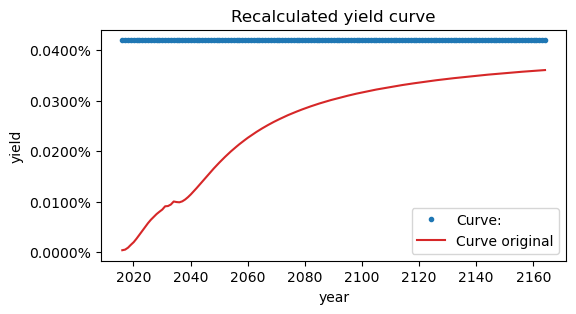

In [81]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(periods_date, r_Target.values, color='tab:blue',label="Curve:", marker='.', linestyle='')
ax1.plot(periods_date, one_curve_sized.loc[:,["spot_rate"]].values, color='tab:red',label="Curve original",  linestyle='-')

ax1.set_ylabel("yield")
ax1.set_title('Recalculated yield curve')
ax1.set_xlabel("year")
ax1.legend()
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

In [82]:
np.max(r_Target.values -one_curve_sized.loc[:,["spot_rate"]].values)

0.04159000000000004

## All together

Note that submisions until 2015/11 have different names.

Check error with EU

In [41]:
list_countries = ["AT","AU","BE","BG","CA","CH","CN","CO","CY","CZ","DE","DK","EE","ES","EU","FI","FR","GR","HK","HR","HU","IE","IS","IT","JP","LI","LT","LU","LV","MT","NL","NO","PL","PT","RO","SE","SI","SK","TW","UK","US"]
#list_dates = ["2014-12-31","2015-01-31","2015-02-28","2015-03-31","2015-04-30","2015-05-31","2015-06-30","2015-07-31","2015-08-31","2015-09-30","2015-10-31","2015-11-30","2015-12-31","2016-01-31","2016-02-29","2016-03-31","2016-04-30","2016-05-31","2016-06-30","2016-07-31","2016-08-31","2016-09-30","2016-10-31","2016-11-30","2016-12-31","2017-01-31","2017-02-28","2017-03-31","2017-04-30","2017-05-31","2017-06-30","2017-07-31","2017-08-31","2017-09-30","2017-10-31","2017-11-30","2017-12-31","2018-01-31","2018-02-28","2018-03-31","2018-04-30","2018-05-31","2018-06-30","2018-07-31","2018-08-31","2018-09-30","2018-10-31","2018-11-30","2018-12-31","2019-01-31","2019-02-28","2019-03-31","2019-04-30","2019-05-31","2019-06-30","2019-07-31","2019-08-31","2019-09-30","2019-10-31","2019-11-30","2019-12-31","2020-01-31","2020-02-29","2020-03-31","2020-04-30","2020-05-31","2020-06-30","2020-07-31","2020-08-31","2020-09-30","2020-10-31","2020-11-30","2020-12-31","2021-01-31","2021-02-28","2021-03-31","2021-04-30","2021-05-31","2021-06-30","2021-07-31","2021-08-31","2021-09-30","2021-10-31","2021-11-30","2021-12-31","2022-01-31","2022-02-28","2022-03-31","2022-04-30","2022-05-31","2022-06-30","2022-07-31","2022-08-31","2022-09-30","2022-10-31","2022-11-30","2022-12-31","2023-01-31","2023-02-28","2023-03-31","2023-04-30","2023-05-31","2023-06-30","2023-07-31","2023-08-31","2023-09-30","2023-10-31","2023-11-30","2023-12-31","2024-01-31","2024-02-29","2024-03-31","2024-04-30","2024-05-31","2024-06-30","2024-07-31","2024-08-31","2024-09-30","2024-10-31","2024-11-30","2024-12-31","2025-01-31","2025-02-28","2025-03-31","2025-04-30","2025-05-31","2025-06-30","2025-07-31","2025-08-31","2025-09-30","2025-10-31","2025-11-30","2025-12-31","2026-01-31","2026-02-28"]
list_dates = ["2015-11-30","2015-12-31","2016-01-31","2016-02-29","2016-03-31","2016-04-30","2016-05-31","2016-06-30","2016-07-31","2016-08-31","2016-09-30","2016-10-31","2016-11-30","2016-12-31","2017-01-31","2017-02-28","2017-03-31","2017-04-30","2017-05-31","2017-06-30","2017-07-31","2017-08-31","2017-09-30","2017-10-31","2017-11-30","2017-12-31","2018-01-31","2018-02-28","2018-03-31","2018-04-30","2018-05-31","2018-06-30","2018-07-31","2018-08-31","2018-09-30","2018-10-31","2018-11-30","2018-12-31","2019-01-31","2019-02-28","2019-03-31","2019-04-30","2019-05-31","2019-06-30","2019-07-31","2019-08-31","2019-09-30","2019-10-31","2019-11-30","2019-12-31","2020-01-31","2020-02-29","2020-03-31","2020-04-30","2020-05-31","2020-06-30","2020-07-31","2020-08-31","2020-09-30","2020-10-31","2020-11-30","2020-12-31","2021-01-31","2021-02-28","2021-03-31","2021-04-30","2021-05-31","2021-06-30","2021-07-31","2021-08-31","2021-09-30","2021-10-31","2021-11-30","2021-12-31","2022-01-31","2022-02-28","2022-03-31","2022-04-30","2022-05-31","2022-06-30","2022-07-31","2022-08-31","2022-09-30","2022-10-31","2022-11-30","2022-12-31","2023-01-31","2023-02-28","2023-03-31","2023-04-30","2023-05-31","2023-06-30","2023-07-31","2023-08-31","2023-09-30","2023-10-31","2023-11-30","2023-12-31","2024-01-31","2024-02-29","2024-03-31","2024-04-30","2024-05-31","2024-06-30","2024-07-31","2024-08-31","2024-09-30","2024-10-31","2024-11-30","2024-12-31","2025-01-31","2025-02-28","2025-03-31","2025-04-30","2025-05-31","2025-06-30","2025-07-31","2025-08-31","2025-09-30","2025-10-31","2025-11-30","2025-12-31","2026-01-31","2026-02-28"]
is_va_str = "no_VA"
num_years = 150

In [42]:
for country_tmp in list_countries:
    print(country_tmp)
    for reference_date_str_tmp in list_dates:
        reference_year = int(reference_date_str_tmp[:4])
        reference_month = int(reference_date_str_tmp[5:7])
        reference_day = int(reference_date_str_tmp[8:])
        
        one_Qb = filter_df_for_selection(all_Qb, reference_date_str_tmp, country_tmp, is_va_str)
        one_param = filter_df_for_selection(all_params, reference_date_str_tmp, country_tmp, is_va_str)
        Qb = one_Qb.loc[:,"qb_value"].values
        ufr = one_param.loc[:,"ufr"].values[0]/100
        alpha = one_param.loc[:,"alpha"].values[0]
        M_Target =  np.transpose(np.arange(1, num_years))

        M_Obs = np.transpose(np.array(list(one_Qb.loc[:,"term_index"].values)))
        r_Target = SWExtrapolate(M_Target,M_Obs, Qb, ufr, alpha)
        r_Target = pd.DataFrame(r_Target,columns=['Recalculated rates'], index = M_Target)
        
        one_curve = filter_df_for_selection(all_curves, reference_date_str_tmp, country_tmp, is_va_str)
        one_curve_sized = one_curve.iloc[:(num_years-1),:]

        max_diff = np.max(r_Target.values -one_curve_sized.loc[:,["spot_rate"]].values)
        if max_diff > 0.00001:
            print(country_tmp)
            print(reference_date_str_tmp)
            print(max_diff)

EU
2015-11-30
0.04427000000000004
EU
2015-12-31
0.04357000000000004
EU
2016-01-31
0.04475000000000004
EU
2016-02-29
0.045170000000000037
EU
2016-03-31
0.044490000000000036
EU
2016-04-30
0.04445000000000004
EU
2016-05-31
0.04461000000000004
EU
2016-06-30
0.04504000000000004
EU
2016-07-31
0.045170000000000037
EU
2016-08-31
0.04508000000000004
EU
2016-09-30
0.04522000000000004
EU
2016-10-31
0.04493000000000004
EU
2016-11-30
0.045010000000000036
EU
2016-12-31
0.04502000000000004
EU
2017-01-31
0.045190000000000036
EU
2017-02-28
0.04516000000000004
EU
2017-03-31
0.04518000000000004
EU
2017-04-30
0.045280000000000035
EU
2017-05-31
0.045370000000000035
EU
2017-06-30
0.045350000000000036
EU
2017-07-31
0.045480000000000034
EU
2017-08-31
0.045600000000000036
EU
2017-09-30
0.04556000000000004
EU
2017-10-31
0.045660000000000034
EU
2017-11-30
0.04554000000000004
EU
2017-12-31
0.04558000000000004
EU
2018-01-31
0.04412999999999998
EU
2018-02-28
0.04401999999999998
EU
2018-03-31
0.04411999999999998
EU


IndexError: index 0 is out of bounds for axis 0 with size 0